## Hyperparameter Tuning with Tensorflow and KerasTuner

Author: Nik Alleyne Author Blog: https://www.securitynik.com Author GitHub: github.com/securitynik

Author Books: [

        "https://www.amazon.ca/Learning-Practicing-Leveraging-Practical-Detection/dp/1731254458/", <br>
        "https://www.amazon.ca/Learning-Practicing-Mastering-Network-Forensics/dp/1775383024/" <br>,
        "https://drive.google.com/file/d/1Ry5r659n8G9Hk8Z8pSKLtqrYyWl8ipbs/view"
    ] 

In [1]:
# let's get our libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [2]:
# Get the datasets
X, y = make_classification(
    n_samples=5000,
    n_features=6,
    n_informative=4,
    n_redundant=2,
    n_classes=3,
    n_clusters_per_class=2,
    weights=None,
    class_sep=1.0,
    random_state=42
)

print(f'Raw data shape: X: {X.shape} -> y: {y.shape}')

# With the data in place, let's split it now
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, train_size=0.7, stratify=y, random_state=42)

print(f'Train shape: {X_train.shape} -> y: {y_train.shape}')

# tmp is not splitted into test and validation
X_test, X_val, y_test, y_val = train_test_split(X_tmp, y_tmp, train_size=0.5, stratify=y_tmp, random_state=10)

# Now take the test 
print(f'After splitting: X_test: {X_test.shape} -> y test: {y_test.shape} ')
print(f'Validation Split: X_val: {X_val.shape} -> y test: {y_val.shape} ')

Raw data shape: X: (5000, 6) -> y: (5000,)
Train shape: (3500, 6) -> y: (3500,)
After splitting: X_test: (750, 6) -> y test: (750,) 
Validation Split: X_val: (750, 6) -> y test: (750,) 


In [3]:
# With the data in place, let's scale the data via standardization
from sklearn.preprocessing import StandardScaler

In [4]:
# Setup the scaler
scaler = StandardScaler()

# Scale the data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

# What is the mean and standard deviation of the training data
print(f'Training data mean: {X_train_scaled.mean()}')
print(f'Training data mean: {X_train_scaled.std()}')

Training data mean: -3.4173722053223866e-17
Training data mean: 1.0000000000000002


In [5]:
# Setup the data for Tensorflow
X_train_tf = X_train_scaled.astype(np.float32)
X_test_tf = X_test_scaled.astype(np.float32)
X_val_tf = X_val_scaled.astype(np.float32)

y_train_tf = y_train.astype(np.int32)
y_test_tf = y_test.astype(np.int32)
y_val_tf = y_val.astype(np.int32)

In [6]:
# Our ys are currently 0, 1, 2 for the 3 classes
# As a result, we will use Sparse Categorical Crossentropy class
np.unique(y)

array([0, 1, 2])

In [7]:
# Define the output shape
NUM_CLASSES = 3

# input dimension
INPUT_DIM = X.shape[1]
NUM_CLASSES, INPUT_DIM

(3, 6)

In [8]:
# Define the search space
# These are the values for which Hyperband should find the best combination
SEARCH_SPACE = {
    "num_layers": [1, 2, 3],
    "units_per_layer": [32, 64, 128],
    "activation": ["relu", "tanh", "elu"],
    "dropout_rate": [0.0, 0.1, 0.2, 0.4],
    "learning_rate": [1e-4, 3e-4, 1e-3],
}

# with this search space, how many possible combinations we have
num_possible_configs = np.prod([ len(value) for value in SEARCH_SPACE.values() ])

print(f'Possible configurations: {num_possible_configs} ')

Possible configurations: 324 


In [9]:
# Setup a sample config
example_config = {
    "num_layers": 2,
    "units_per_layer": 64,
    "activation": "relu",
    "dropout_rate": 0.2,
    "learning_rate": 1e-3,
}


In [10]:
# Define the training config
# These are fixed
TRAINING_CONFIG = {
    "max_epochs": 3,
    "batch_size": 64,
    "random_seed": 42,
}


In [11]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress INFO and WARNING messages

import tensorflow as tf

# With the core items in place, let's build the Tensorflow model
# Make sure you also have tensorboard installed

import tensorflow as tf

In [12]:
# Let's setup a build structure, so we can test our ideas first
def build_tf_model(config:dict=example_config):
    ''' Builds and compile the Tensorflow model '''

    # Set the seed
    tf.keras.utils.set_random_seed(
        TRAINING_CONFIG['random_seed']
    )

    # Setup the model container
    model = tf.keras.Sequential(name='dynamic_classifier')

    # Add the input layer
    model.add(tf.keras.layers.Input(shape=(INPUT_DIM,)))

    for layer_idx in range(config['num_layers']):
        model.add(tf.keras.layers.Dense(
            units=config['units_per_layer'],  
            activation=config['activation'],
            name=f'hidden_layer_{layer_idx + 1}'
            )   
        )

        # Should we use dropout? 
        if config['dropout_rate'] > 0.0:
            model.add(
                tf.keras.layers.Dropout(
                    rate=config['dropout_rate'],
                    name=f'dropout_{layer_idx + 1}'
                )
            )

    # Add the output layer
    model.add( tf.keras.layers.Dense(
        units=NUM_CLASSES,
        name='output_layer'
    ))

    # Define the optimizer
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=config['learning_rate']
    )

    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True
        ),
        metrics =[
            tf.keras.metrics.SparseCategoricalAccuracy(
                name='accuracy'
            )
        ]
    )

    return model

In [13]:
# Test the core model config
tf_model  =  build_tf_model()

# Get the model summary
tf_model.summary()

I0000 00:00:1789702827.873356   11284 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13245 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080 Laptop GPU, pci bus id: 0000:64:00.0, compute capability: 12.0


Model: "dynamic_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,803 (18.76 KB)

 Trainable params: 4,803 (18.76 KB)

 Non-trainable params: 0 (0.00 B)

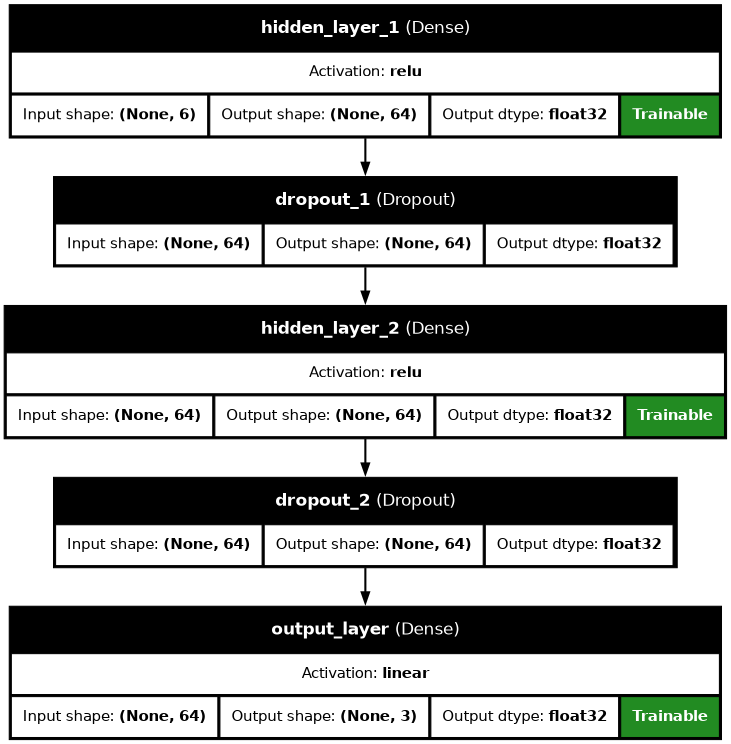

In [14]:
# Plot the network to see 
tf.keras.utils.plot_model(tf_model, show_shapes=True, show_dtype=True, show_layer_activations=True, show_layer_names=True, show_trainable=True, dpi=75)

In [15]:
# Do a quick train, to ensure all is well before we bring in KerasTuner
history = tf_model.fit(
    X_train_tf, 
    y_train_tf,
    validation_data = (X_val_tf, y_val_tf),
    epochs=1,
    batch_size=TRAINING_CONFIG['batch_size'],
    verbose=1

)

I0000 00:00:1789702831.668659   11351 cuda_dnn.cc:530] Loaded cuDNN version 92400


18/55 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5052 - loss: 1.0030

I0000 00:00:1789702850.598315   11351 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


55/55 ━━━━━━━━━━━━━━━━━━━━ 54s 615ms/step - accuracy: 0.6417 - loss: 0.8510 - val_accuracy: 0.7787 - val_loss: 0.6403


In [16]:
# If everything works well, let's us now evaluate the model
test_loss, test_accuracy = tf_model.evaluate(
    X_test_tf, y_test_tf, verbose=0
)

print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

Test Loss: 0.6532637476921082
Test Accuracy: 0.762666642665863


In [17]:
# Let us also ensure mlflow is running. In my cases I load it with
# $ mlflow server --port 9999 --backend-store-uri sqlite:///mlflow.db

In [18]:
# Now that we know the structure works. 
# Time to introduce KerasTuner
import keras_tuner as kt

In [19]:
# We know our structure above for the model we built earlier. 
# We basically take the what we designed above, and modify it for KerasTuner

# Let's setup a build structure, so we can test our ideas first
def build_tf_model_tuner(hp):
    ''' Builds and compile the Tensorflow model for hyperparameter tuning '''

    # Set the seed
    tf.keras.utils.set_random_seed(
        TRAINING_CONFIG['random_seed']
    )

    # Read the max number of layers
    num_layers = hp.Choice(
        name='num_layers',
        values=SEARCH_SPACE['num_layers']
    )

    # How many neurons per layer?
    units_per_layer = hp.Choice(
        name='units_per_layer',
        values=SEARCH_SPACE['units_per_layer']
    )

    # Which activation function use?
    activation = hp.Choice(
        name='activation',
        values=SEARCH_SPACE['activation']
    )

    # Dropout
    dropout_rate = hp.Choice(
        name='dropout_rate',
        values=SEARCH_SPACE['dropout_rate']
    )

    learning_rate = hp.Choice(
        name='learning_rate',
        values=SEARCH_SPACE['learning_rate']
    )

    # Setup the model container
    model = tf.keras.Sequential(name='dynamic_classifier_TUNER')

    # Add the input layer
    model.add(tf.keras.layers.Input(shape=(X_train_tf.shape[1],)))

    for layer_idx in range(num_layers):
        model.add(tf.keras.layers.Dense(
            units=units_per_layer,  
            activation=activation,
            name=f'hidden_layer_{layer_idx + 1}'
            )   
        )

        # Should we use dropout? 
        if dropout_rate > 0.0:
            model.add(
                tf.keras.layers.Dropout(
                    rate=dropout_rate,
                    name=f'dropout_{layer_idx + 1}'
                )
            )

    # Add the output layer
    model.add( tf.keras.layers.Dense(
        units=NUM_CLASSES,
        name='output_layer'
        )
    )

    # Define the optimizer
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True
        ),
        metrics =[
            tf.keras.metrics.SparseCategoricalAccuracy(
                name='accuracy'
            )
        ]
    )

    return model

In [20]:
# Import json to help with the display
import json

In [21]:
# Test the model
# First instantiate the KT Hyperparameters
hp = kt.HyperParameters()

# Setup the model
test_tuner_model = build_tf_model_tuner(hp=hp)

# Since we have not run the loop as yet, let's see what the model cam eup with 
print(f'Current Hyperparameter values: \n{json.dumps(hp.values, indent=2)}')

# Get the tuner model summary
test_tuner_model.summary()

Current Hyperparameter values: 
{
  "num_layers": 1,
  "units_per_layer": 32,
  "activation": "relu",
  "dropout_rate": 0.0,
  "learning_rate": 0.0001
}


Model: "dynamic_classifier_TUNER"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323 (1.26 KB)

 Trainable params: 323 (1.26 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# With that working, time to now create the Hyperband tuner
# Remember, keeping things simple only for demo purposes
tuner = kt.Hyperband(
    hypermodel=build_tf_model_tuner,
    objective=kt.Objective('val_accuracy', direction='max'),
    max_epochs=TRAINING_CONFIG['max_epochs'],
    factor=3,
    hyperband_iterations=1,
    directory='keras_tuner_results',
    project_name='tf_dynamic_classifier',
    overwrite=True,
    seed=TRAINING_CONFIG['random_seed']
)

tuner

In [23]:
# Set the seed
tf.keras.utils.set_random_seed(
    TRAINING_CONFIG['random_seed']
)

# Run the search
# This is where the hyperparameter searching is actually done
# What will happen is KerasTuner will construct different architectures
# train them and use the val_accuracy to decide which trials should continue
# and which should be discarded.

tuner.search(
    X_train_tf,
    y_train_tf,
    validation_data=(X_val_tf,y_val_tf
    ),
    epochs=TRAINING_CONFIG['max_epochs'],
    batch_size=TRAINING_CONFIG['batch_size'],
    verbose=1
)

Trial 6 Complete [00h 00m 29s]
val_accuracy: 0.6386666893959045

Best val_accuracy So Far: 0.8759999871253967
Total elapsed time: 00h 02m 20s


In [24]:
# With this done, let's inspect the best configurations
# Realistically, it sorts all the trials in order
# The one with the best score is usually first
# Just using num_trials=2 here to extract the top 2
tuner.results_summary(num_trials=2)

Results summary
Results in keras_tuner_results/tf_dynamic_classifier
Showing 2 best trials
Objective(name="val_accuracy", direction="max")

Trial 0003 summary
Hyperparameters:
num_layers: 3
units_per_layer: 64
activation: elu
dropout_rate: 0.0
learning_rate: 0.001
tuner/epochs: 3
tuner/initial_epoch: 1
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0002
Score: 0.8759999871253967

Trial 0002 summary
Hyperparameters:
num_layers: 3
units_per_layer: 64
activation: elu
dropout_rate: 0.0
learning_rate: 0.001
tuner/epochs: 1
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.7546666860580444


In [25]:
# Let us get the best hyperparameters now
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f'Here is the best set of hyperparameters')
for name, value in best_hp.values.items():
    print(f'{name}:{value}')

Here is the best set of hyperparameters
num_layers:3
units_per_layer:64
activation:elu
dropout_rate:0.0
learning_rate:0.001
tuner/epochs:3
tuner/initial_epoch:1
tuner/bracket:1
tuner/round:1
tuner/trial_id:0002


In [26]:
# Let us use this to build the best model during the search
best_model = tuner.get_best_models(num_models=1)[0]

# Let's evaluate the model on the test set
# While this approach works, the reality is, 
# we should train a final model using this architecture
# before considering deploying to production

test_loss, test_accuracy = best_model.evaluate(X_test_tf, y_test_tf)
print(f'Test loss on tuned model: {test_loss}')
print(f'Test Accuracy on tuned model: {test_accuracy}')

24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 210ms/step - accuracy: 0.8613 - loss: 0.4317
Test loss on tuned model: 0.4316519498825073
Test Accuracy on tuned model: 0.8613333106040955


In [27]:
trial = next(iter(tuner.oracle.trials.values()))
trial.metrics.metrics.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [28]:
tf_model.save('/tmp/tf_model.keras')